In [21]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPool2D, Dropout, BatchNormalization
from keras.datasets import mnist
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Loading and Preprossing data

In [22]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()


In [23]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


# Reshaping the data to fit the model

In [24]:

X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

In [25]:
print('The shape of the training inputs:', X_train.shape)
print('The shape of the training labels:',y_train.shape)
print('The shape of the testing inputs:',X_test.shape)
print('The shape of the testing labels:',y_test.shape)

The shape of the training inputs: (60000, 28, 28, 1)
The shape of the training labels: (60000,)
The shape of the testing inputs: (10000, 28, 28, 1)
The shape of the testing labels: (10000,)


# One-Hot Encoding:

In [26]:
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

print(y_train_one_hot[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# Build Improved CNN Model

In [27]:
model = Sequential()

## First Convolutional Block


In [28]:
model.add(Conv2D(32, kernel_size=3, activation='relu', input_shape=(28, 28, 1)))
model.add(BatchNormalization())

## Second Convolutional Block


In [29]:
model.add(Conv2D(64, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))

# Third Convolutional Block


In [30]:
model.add(Conv2D(128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

## Fully Connected Layers


In [31]:
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Prevent overfitting
model.add(Dense(10, activation='softmax'))  # Output layer

In [32]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,586 (1.92 MB)

 Trainable params: 504,138 (1.92 MB)

 Non-trainable params: 448 (1.75 KB)

#  Compile Model

In [33]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks for better training


In [34]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=0.00001
)

# Train the model


In [35]:
hist = model.fit(
    X_train, y_train_one_hot,
    validation_data=(X_test, y_test_one_hot),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8551 - loss: 0.5203 - val_accuracy: 0.9843 - val_loss: 0.0483 - learning_rate: 0.0010
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9716 - loss: 0.0973 - val_accuracy: 0.9871 - val_loss: 0.0390 - learning_rate: 0.0010
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9786 - loss: 0.0749 - val_accuracy: 0.9903 - val_loss: 0.0318 - learning_rate: 0.0010
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9820 - loss: 0.0626 - val_accuracy: 0.9904 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9851 - loss: 0.0513 - val_accuracy: 0.9918 - val_loss: 0.0279 - learning_rate: 0.0010
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9864 - loss: 0.0467 - val_accuracy: 0.9929 - val_loss: 0.0247 - learning_rate: 0.0010
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9881 - loss: 0

# Evaluate on test set


In [36]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_one_hot, verbose=0)

print("\n" + "="*50)
print(" FINAL TEST RESULTS")
print("="*50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*50)



 FINAL TEST RESULTS
Test Loss: 0.0211
Test Accuracy: 0.9950 (99.50%)


# Plot accuracy



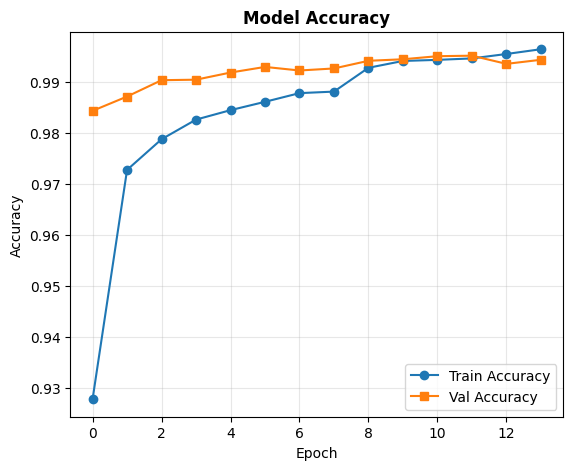

In [37]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(hist.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)



# Plot loss


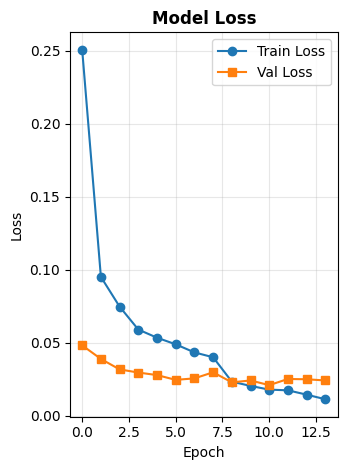

In [38]:
plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='Train Loss', marker='o')
plt.plot(hist.history['val_loss'], label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

print(f"✅ Made predictions for {len(predictions):,} test images")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
✅ Made predictions for 10,000 test images


# Visualize some predictions


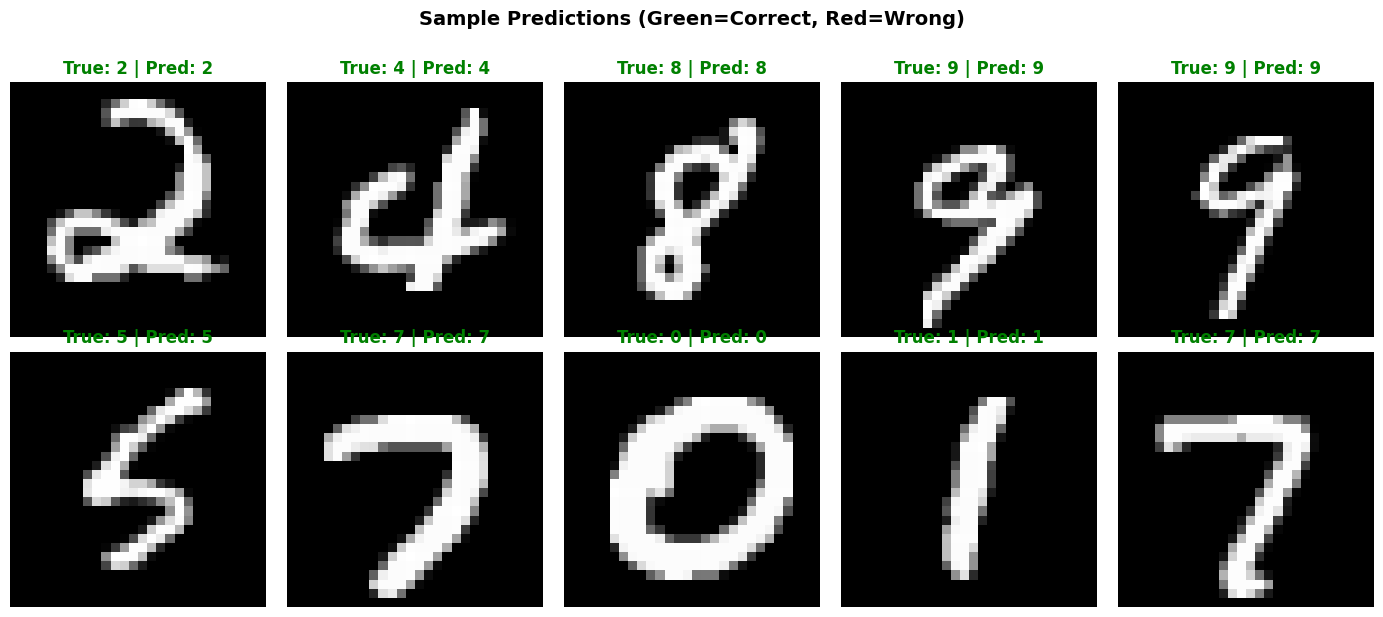

In [40]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    # Get random index
    idx = np.random.randint(0, len(X_test))

    # Display image
    img = X_test[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')

    # Get prediction and true label
    pred = predicted_classes[idx]
    true = y_test[idx]

    # Color: green if correct, red if wrong
    color = 'green' if pred == true else 'red'
    ax.set_title(f'True: {true} | Pred: {pred}', color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [41]:
model.save('mnist_improved_model.h5')
